In [1]:
# Import libraries

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)


In [2]:
# Load dataset and inspect columns
df = pd.read_parquet('NF-BoT-IoT-V2.parquet')

print("Columns:\n", df.columns)

label_column = 'Attack' # This column contains the attack categories or normal traffic labels


Columns:
 Index(['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES',
       'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS',
       'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN',
       'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label', 'Attack'],
      dtype='str')


In [3]:
# split features and & target variable

X = df.drop(label_column, axis=1)
y = df[label_column]

# Encode target labels if they are categorical
le = LabelEncoder()
y = le.fit_transform(y)

# Handle missing values (if any) - here we fill them with the median of each column
X = X.fillna(0)


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [5]:
# LightGBM datasets for training and testing

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

# Set LightGBM model parameters directly in the train function

model = lgb.LGBMClassifier(
    objective='multiclass', # Use 'multiclass' for multi-class classification
    num_class=len(np.unique(y)), # Set the number of classes based on unique labels

    n_estimators=500, # Number of boosting rounds
    learning_rate=0.05, # Learning rate

    num_leaves=64, # Maximum number of leaves in one tree
    max_depth=-1, # No limit on tree depth
    min_child_samples=20, # Minimum number of samples required to be at a leaf node

    subsample=0.8, # Subsample ratio of the training instances
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree

    n_jobs=-1, # Use all available CPU cores
    class_weight='balanced', # Handle class imbalance by adjusting weights inversely proportional to class frequencies
    random_state=42, # For reproducibility
    
)


In [6]:
# Train the model

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=25)
    ]
)

print(f"\nBest iteration: {model.best_iteration_}")

# save the model
model.booster_.save_model('lightgbm_model.txt')
print("Model saved to 'lightgbm_model.txt'")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.966433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2562
[LightGBM] [Info] Number of data points in the train set: 24336068, number of used features: 42
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[25]	valid_0's multi_logloss: 0.208047
[50]	valid_0's multi_logloss: 0.0671767
[75]	valid_0's multi_logloss: 0.0423605
[100]	valid_0's multi_logloss: 0.0346461
[125]	valid_0's multi_logloss: 0.029927
[150]	valid_0's multi_logloss: 0.0268866
[175]	valid_0's multi_logloss: 0.0246345
[200]	valid_0's multi_logloss: 

In [ ]:
# Prediction and metrics

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

# Print metrics
print("\n=====METRICS=====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# compare training vs test accuracy
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference (Train - Test): {train_accuracy - test_accuracy:.4f}")



=====METRICS=====
Accuracy: 0.9948
Precision: 0.9949
Recall: 0.9948
F1 Score: 0.9948
ROC AUC Score: 0.9999

Classification Report:
                 precision    recall  f1-score   support

        Benign       1.00      1.00      1.00     25887
          DDoS       1.00      1.00      1.00   2856052
           DoS       1.00      0.99      0.99   2729012
Reconnaissance       0.96      0.99      0.98    472604
         Theft       0.73      0.91      0.81       463

      accuracy                           0.99   6084018
     macro avg       0.94      0.98      0.96   6084018
  weighted avg       0.99      0.99      0.99   6084018



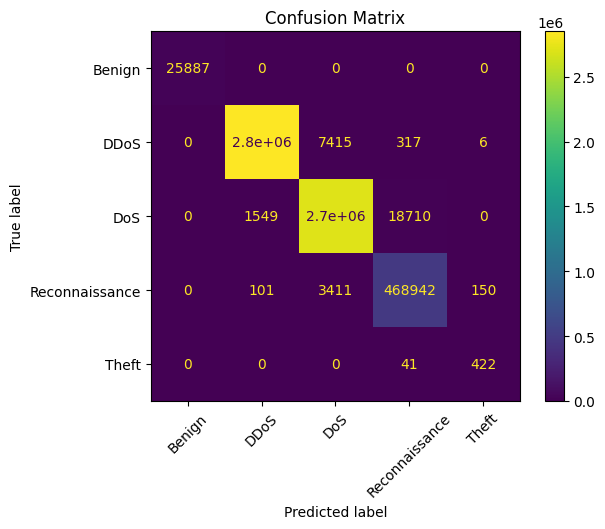

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout
plt.savefig('lightgbm_confusion_matrix.png', dpi=150)
plt.show()

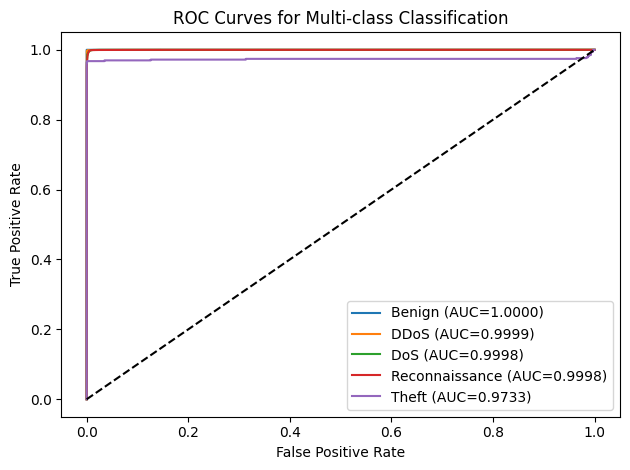

In [ ]:
# ROC Curves for multi-class classification

y_test_bin = label_binarize(y_test, classes=np.unique(y))
plt.figure()
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={roc_auc_class:.4f})")

plt.plot([0, 1], [0, 1], 'k--') # Diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multi-class Classification")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('lightgbm_roc_curves.png', dpi=150)
plt.show()

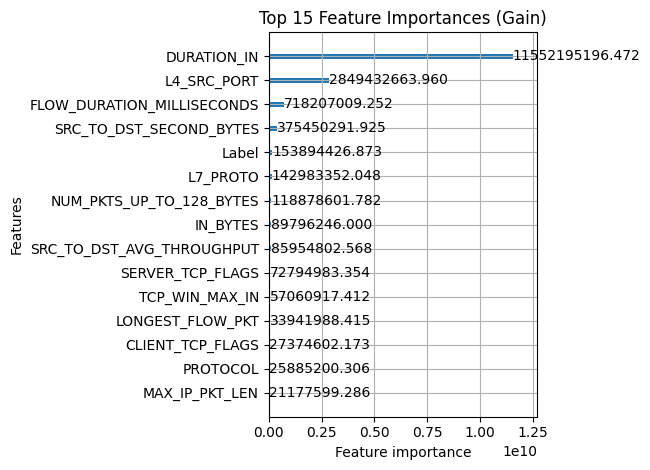

In [ ]:
# Feature importance plot
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Feature Importances (Gain)")
plt.tight_layout()
plt.savefig('lightgbm_feature_importance.png', dpi=150)
plt.show()